In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read csv
df = pd.read_csv('eda_data.csv')

In [3]:
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,age,python_yn,R_yn,spark,aws,excel,job_simp,seniority,desc_len,num_comp
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,...,47,1,0,0,0,1,data scientist,na,2536,0
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,...,36,1,0,0,0,0,data scientist,na,4783,0
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,...,10,1,0,1,0,1,data scientist,na,3461,0
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,...,55,1,0,0,0,0,data scientist,na,3883,3
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,...,22,1,0,0,0,1,data scientist,na,2728,3


In [4]:
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'R_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_len',
       'num_comp'],
      dtype='object')

In [5]:
# Create a new column 'contains_AWS' to check for the presence of 'AWS'
df['contains_AWS'] = df['Job Description'].apply(lambda x: 'AWS' in x)

df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,python_yn,R_yn,spark,aws,excel,job_simp,seniority,desc_len,num_comp,contains_AWS
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,...,1,0,0,0,1,data scientist,na,2536,0,False
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,...,1,0,0,0,0,data scientist,na,4783,0,False
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,...,1,0,1,0,1,data scientist,na,3461,0,False
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,...,1,0,0,0,0,data scientist,na,3883,3,False
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,...,1,0,0,0,1,data scientist,na,2728,3,False


In [6]:
# number of job descriptions with "AWS"
aws_count = df['contains_AWS'].sum()
aws_count

119

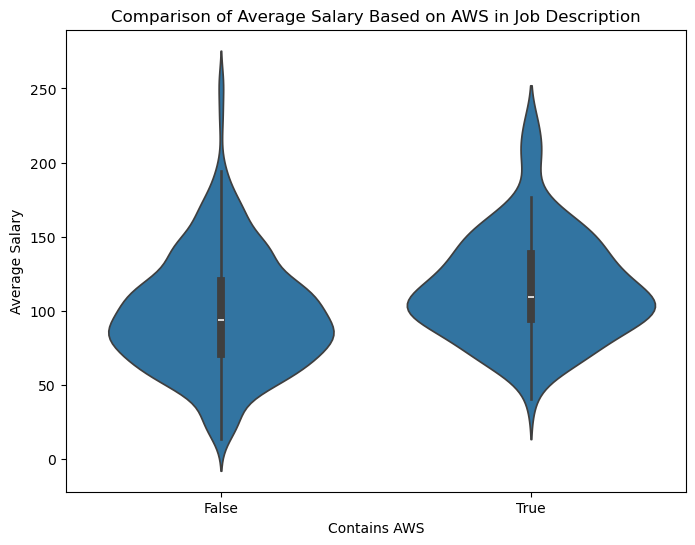

In [7]:
# Create the violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='contains_AWS', y='avg_salary', data=df)

# Set plot labels and title
plt.xlabel('Contains AWS')
plt.ylabel('Average Salary')
plt.title('Comparison of Average Salary Based on AWS in Job Description')

# Show the plot
plt.show()

c:\Users\kaoji\anaconda3\envs\dats6103\lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
c:\Users\kaoji\anaconda3\envs\dats6103\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


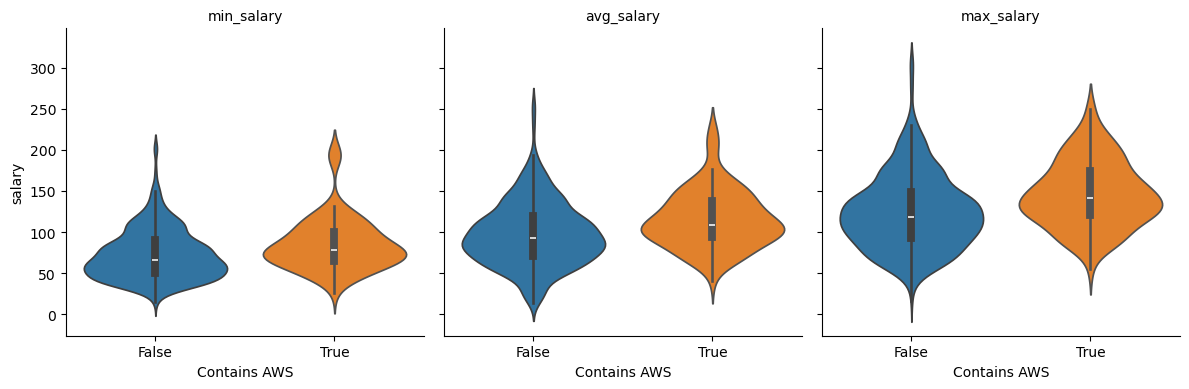

In [8]:
# Melt the dataframe to long format for easier plotting
df_melted = df.melt(id_vars=['contains_AWS'], value_vars=['min_salary', 'avg_salary', 'max_salary'],
                    var_name='salary_type', value_name='salary')

# Create a FacetGrid for 6 separate violin plots
g = sns.FacetGrid(df_melted, col='salary_type', hue='contains_AWS', col_wrap=3, height=4)

# Map the violinplot to each facet
g.map(sns.violinplot, 'contains_AWS', 'salary')

# Set plot labels and title
g.set_axis_labels('Contains AWS', 'salary')
g.set_titles("{col_name}")

# Show the plot
plt.show()

In [9]:
# Group by 'contains_AWS' and calculate the mean for min_salary, average_salary, and max_salary
average_table = df.groupby('contains_AWS')[['min_salary', 'avg_salary', 'max_salary']].mean()

# Display the table
print(average_table)

              min_salary  avg_salary  max_salary
contains_AWS                                    
False          72.654896   97.707063  124.685393
True           85.529412  115.907563  146.285714
